# Stage 1: Load and Initial Inspection of EEG Signals

## Import Required Libraries

In [1]:
import mne                     # EEG analysis library
import numpy as np              # Numerical computations
import matplotlib.pyplot as plt # Plotting
import os


## Load EEG Data (EDF Files)

In [2]:
file_eyes_open = r"data\S001R01.edf"   # Baseline, Eyes Open
file_eyes_closed = r"data\S001R02.edf" # Baseline, Eyes Closed

# Load EDF files using MNE
# preload=True loads data into memory for faster access
#When verbose=False, information messages won’t be printed in the output.

raw_open = mne.io.read_raw_edf(file_eyes_open, preload=True, verbose=False)
raw_closed = mne.io.read_raw_edf(file_eyes_closed, preload=True, verbose=False)

In [3]:
raw_open

<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>

In [4]:
raw_closed

<RawEDF | S001R02.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>

## Inspect Dataset Information

In [5]:
# Sampling frequency (Hz)
sfreq = raw_open.info['sfreq'] #this line reads the sampling frequency of the EEG signal and stores it in the variable sfreq 

# Number of channels
n_channels = len(raw_open.ch_names) 

# Channel names
channel_names = raw_open.ch_names

# Total number of samples in the recording
n_samples = raw_open.n_times   #approximately one minute (60 sec) * 160   = 9760

# Print dataset information
print("----------data set information------------")
print("Sampling Frequency (Hz):", sfreq)
print("Total number of samples:", n_samples)
print("Number of channels:", n_channels)
print("Channel names:")
print(channel_names)

# Confirm that we have 64 EEG channels
assert n_channels == 64, "Expected 64 EEG channels!"

----------data set information------------
Sampling Frequency (Hz): 160.0
Total number of samples: 9760
Number of channels: 64
Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


## Select an Occipital Channel (O1..)

In [6]:
# Occipital(پس سری) channels (O1 / O2) are located at the back of the head
# why should we choose Occipital channel? because These regions are strongly associated with visual processing.
# Alpha rhythm (8–12 Hz) is known to be strongest in occipital areas,especially during eyes-closed resting state.

selected_channel = "O1.."

# Verify that the channel exists in the dataset
assert selected_channel in channel_names, "Selected channel not found!"


## Extract First 10 Seconds of Data

In [7]:
# Duration to extract (seconds)
duration_sec = 10

# Number of samples corresponding to 10 seconds
n_samples_10s = int(duration_sec * sfreq)  #10 * 160 = 1600

# Extract 1600 sample data from the selected channel(which is 01)
# get_data() returns data in Volts
data_open = raw_open.get_data(picks=[selected_channel])[0, :n_samples_10s]   #data_open.shape = (1600,)
data_closed = raw_closed.get_data(picks=[selected_channel])[0, :n_samples_10s] #data_closed.shape = (1600,)

#get_data extracts the EEG/MEG numerical data from the Raw object and returns it as a numpy.ndarray

# Create time vector (seconds) 
time = np.arange(n_samples_10s) / sfreq   #time.shape =  (1600,)
#This line creates a time axis (in seconds) for the EEG signal.


In [8]:
type(data_open)

numpy.ndarray

In [9]:
time   
# time:
#| 0s | 0.006s | 0.012s | ... |

array([0.00000e+00, 6.25000e-03, 1.25000e-02, ..., 9.98125e+00,
       9.98750e+00, 9.99375e+00])

## Plot Time-Domain EEG Signals (Eyes Open vs Eyes Closed)

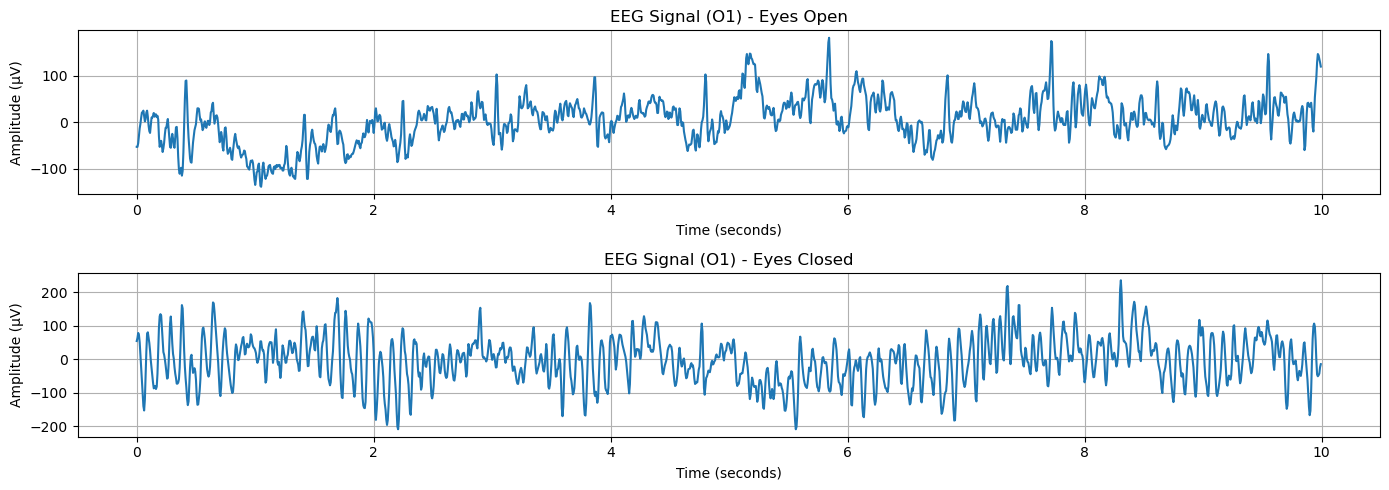

In [10]:
# Create side-by-side plots 
plt.figure(figsize=(14, 5))

# Eyes Open plot
plt.subplot(2, 1, 1)
plt.plot(time, data_open * 1e6)  # Convert Volts to microvolts (µV)
plt.title("EEG Signal (O1) - Eyes Open")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

# Eyes Closed plot
plt.subplot(2, 1, 2)
plt.plot(time, data_closed * 1e6)
plt.title("EEG Signal (O1) - Eyes Closed")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

plt.tight_layout()

filename = os.path.join('generated_pics', "Plot Time-Domain EEG Signals (Eyes Open vs Eyes Closed).png")
plt.savefig(filename, dpi=300)

plt.show()


# Stage 2: EEG Preprocessing

## Remove DC Offset (Mean Removal)

In [11]:
# DC OFFSET REMOVAL:

# EEG amplifiers and electrodes can introduce a constant offset (DC component).
# This offset is not physiologically meaningful and can:
# - Bias amplitude measurements
# - Reduce filter effectiveness
# Therefore, we subtract the mean to center the signal around zero.

# Remove DC offset by subtracting the mean
data_open_dc = data_open - np.mean(data_open)
data_closed_dc = data_closed - np.mean(data_closed)

# Print mean values to confirm DC removal
print("Mean after DC removal (Eyes Open):", np.mean(data_open_dc))
print("Mean after DC removal (Eyes Closed):", np.mean(data_closed_dc))

#removing DC goal?  
#سیگنال حول صفر نوسان کند
#دامنه واقعی سیگنال تغییر نمی‌کند
#فقط مرکز سیگنال اصلاح می‌شود



Mean after DC removal (Eyes Open): -4.336808689942018e-21
Mean after DC removal (Eyes Closed): -8.131516293641283e-22


## Apply Band-Pass Filter (0.5–40 Hz)

In [12]:
from scipy.signal import butter, filtfilt

# BAND-PASS FILTER DESIGN

# Filter settings:
# - Low cutoff: 0.5 Hz (removes slow drifts, sweat artifacts)
# - High cutoff: 40 Hz (removes muscle noise and high-frequency interference)
# - Filter type: Butterworth
# - Order(n): 4 (good balance between sharpness and stability)

lowcut = 0.5   # Hz
highcut = 40.0 # Hz
order = 4

# Nyquist frequency (half the sampling rate)
nyquist = 0.5 * sfreq    #80

# Normalize cutoff frequencies              THIS IS JUST FOR SCIPY UNDERSTANDING, IT WONT CHANGE THE FILTER
low = lowcut / nyquist     #0.00625
high = highcut / nyquist   #0.5

# Design Butterworth band-pass filter
b, a = butter(order, [low, high], btype='bandpass')


# APPLY FILTER

# filtfilt is used instead of lfilter to achieve zero-phase filtering,
# which avoids phase distortion in EEG waveforms.

data_open_filt = filtfilt(b, a, data_open_dc)
data_closed_filt = filtfilt(b, a, data_closed_dc)


## Plot Original vs Filtered Signals (Eyes Open)

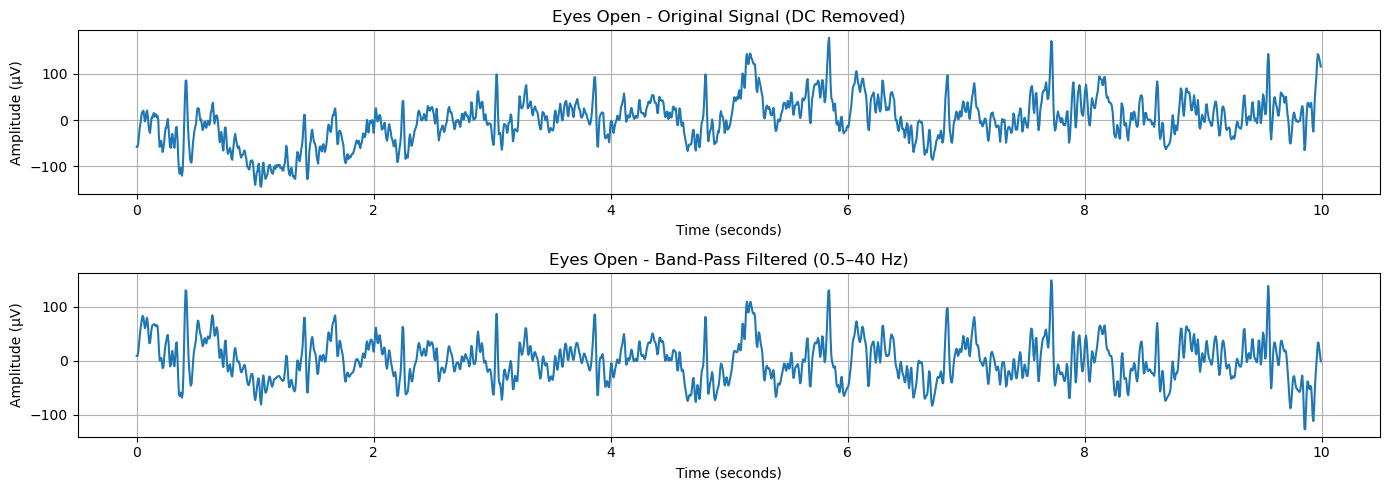

In [13]:
# PLOT: EYES OPEN

plt.figure(figsize=(14, 5))

# Original (DC removed, unfiltered)
plt.subplot(2, 1, 1)
plt.plot(time, data_open_dc * 1e6)
plt.title("Eyes Open - Original Signal (DC Removed)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

# Filtered
plt.subplot(2, 1, 2)
plt.plot(time, data_open_filt * 1e6)
plt.title("Eyes Open - Band-Pass Filtered (0.5–40 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

plt.tight_layout()

filename = os.path.join('generated_pics', "Plot Original vs Filtered Signals (Eyes Open).png")
plt.savefig(filename, dpi=300)

plt.show()


## Plot Original vs Filtered Signals (Eyes Closed)

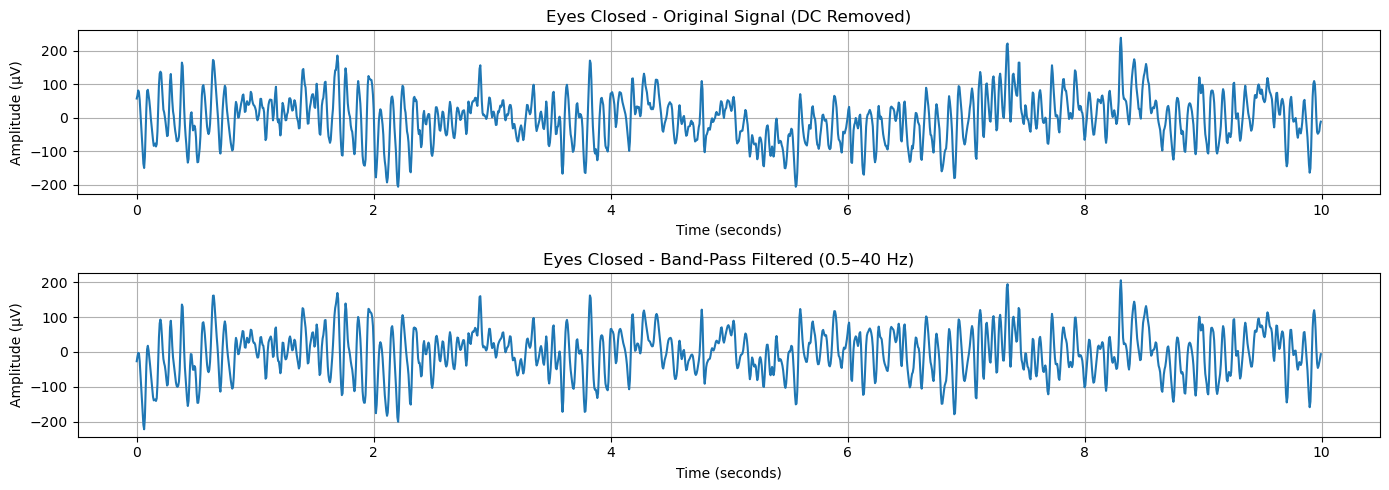

In [14]:
# -----------------------------
# PLOT: EYES CLOSED
# -----------------------------
plt.figure(figsize=(14, 5))

# Original (DC removed, unfiltered)
plt.subplot(2, 1, 1)
plt.plot(time, data_closed_dc * 1e6)
plt.title("Eyes Closed - Original Signal (DC Removed)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

# Filtered
plt.subplot(2, 1, 2)
plt.plot(time, data_closed_filt * 1e6)
plt.title("Eyes Closed - Band-Pass Filtered (0.5–40 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)

plt.tight_layout()

filename = os.path.join('generated_pics', "Plot Original vs Filtered Signals (Eyes Closed).png")
plt.savefig(filename, dpi=300)

plt.show()


# Stage 3: Frequency-Domain Analysis & Signal Reconstruction

## Part A

### Compute FFT and Frequency Axis

In [15]:
# FAST FOURIER TRANSFORM (FFT)

# We use rFFT because EEG signals are real-valued.
# rFFT returns only the positive frequency components,
# which is sufficient for spectral analysis.

# Number of samples
N = len(data_open_filt)   #1600

# Compute FFT for Eyes Open and Eyes Closed, rfft = real fft(because EEG values are real)
fft_open = np.fft.rfft(data_open_filt)  # fft_open.shape = (801,) 
fft_closed = np.fft.rfft(data_closed_filt)

# Construct frequency axis
freqs = np.fft.rfftfreq(N, d=1/sfreq)

# Compute amplitude spectrum (magnitude of FFT)
amp_open = np.abs(fft_open) / N
amp_closed = np.abs(fft_closed) / N


### Plot Amplitude Spectrum (0–40 Hz)

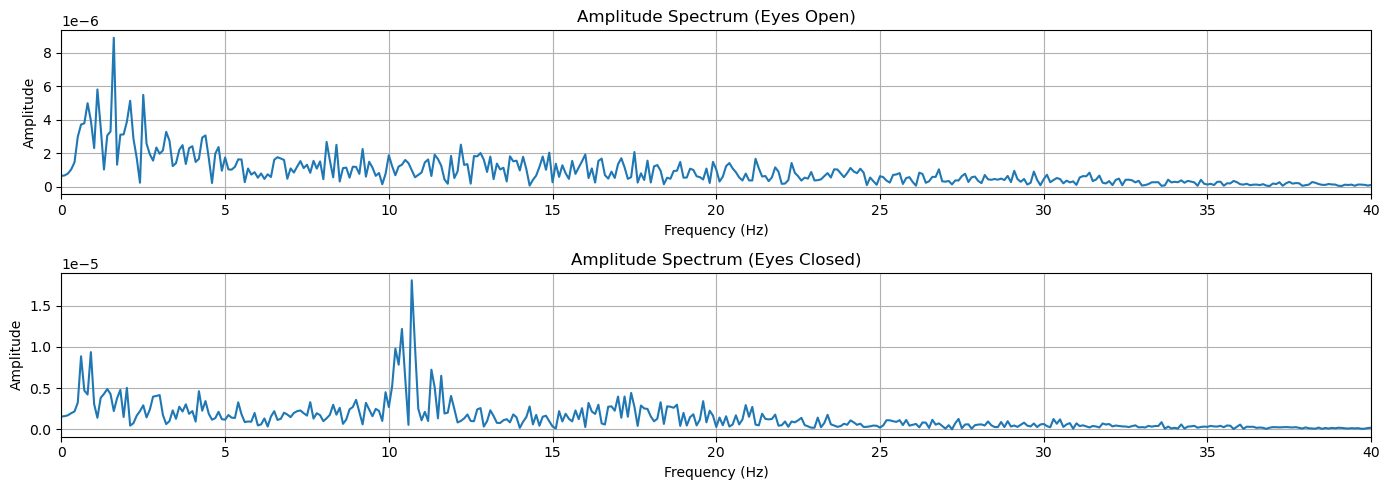

In [16]:
# PLOT AMPLITUDE SPECTRUM

plt.figure(figsize=(14, 5))

# Eyes Open
plt.subplot(2, 1, 1)
plt.plot(freqs, amp_open)
plt.xlim(0, 40)
plt.title("Amplitude Spectrum (Eyes Open)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

# Eyes Closed
plt.subplot(2, 1, 2)
plt.plot(freqs, amp_closed)
plt.xlim(0, 40)
plt.title("Amplitude Spectrum (Eyes Closed)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

filename = os.path.join('generated_pics', "Plot Amplitude Spectrum (0–40 Hz).png")
plt.savefig(filename, dpi=300)

plt.show()


## Part B

### Define EEG Bands and Compute Power

In [17]:
# EEG BAND DEFINITIONS (Hz)

bands = {
    "Delta (0.5–4 Hz)": (0.5, 4),
    "Theta (4–8 Hz)": (4, 8),
    "Alpha (8–12 Hz)": (8, 12),
    "Beta (12–30 Hz)": (12, 30),
    "Gamma (30–40 Hz)": (30, 40)
}

def band_power(fft_data, freqs, band):
    """
    Computes power in a specific frequency band
    by summing squared FFT magnitudes.
    """
    low, high = band
    idx = np.logical_and(freqs >= low, freqs <= high)
    power = np.sum(np.abs(fft_data[idx]) ** 2)
    return power

# Compute band powers for both conditions
power_open = []
power_closed = []

for band in bands.values():
    power_open.append(band_power(fft_open, freqs, band))
    power_closed.append(band_power(fft_closed, freqs, band))


In [18]:
power_open

[0.0010385010319053337,
 0.0002188384888964584,
 0.0001695092264385907,
 0.0003980329382243098,
 2.191057858701236e-05]

In [19]:
power_closed

[0.0012486321293600274,
 0.000380187580938878,
 0.0027633932706789643,
 0.000981269180641257,
 3.735901622469296e-05]

### Plot Band Power Comparison

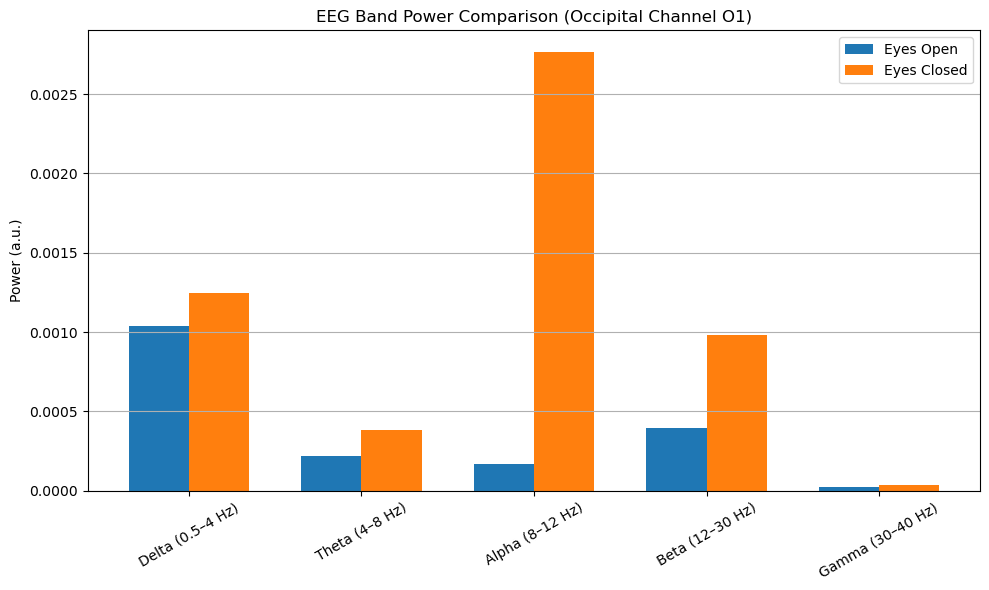

In [20]:
# BAR PLOT: BAND POWER COMPARISON

labels = list(bands.keys())
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, power_open, width, label="Eyes Open")
plt.bar(x + width/2, power_closed, width, label="Eyes Closed")

plt.xticks(x, labels, rotation=30)
plt.ylabel("Power (a.u.)")
plt.title("EEG Band Power Comparison (Occipital Channel O1)")
plt.legend()
plt.grid(axis='y')


plt.tight_layout()

filename = os.path.join('generated_pics', "Plot Band Power Comparison.png")
plt.savefig(filename, dpi=300)

plt.show()


### Power-Line Noise Check (50 Hz)

In [21]:
# POWER-LINE NOISE CHECK

# Power-line interference typically appears at 50 Hz (or 60 Hz).
# Since we applied a 0.5–40 Hz band-pass filter,50 Hz noise should NOT be present.


# Check if any significant energy exists near 50 Hz
# noise_idx will be an array filled with True, false
noise_idx = np.logical_and(freqs >= 48, freqs <= 52)   #بازه ی نویز  
#np.logical_and Creates a Boolean maskو True for frequencies between 48 and 52 Hz False for all other frequencies


print("Power near 50 Hz (Eyes Open):", np.sum(amp_open[noise_idx]))
print("Power near 50 Hz (Eyes Closed):", np.sum(amp_closed[noise_idx]))

# Expected result: very low or near-zero power


Power near 50 Hz (Eyes Open): 3.1792175658152946e-07
Power near 50 Hz (Eyes Closed): 5.457440117122925e-07


In [22]:
noise_idx.shape

(801,)

## Part C

### Reconstruct Time-Domain Signal

In [23]:
# INVERSE FFT (IFFT)

# irFFT reconstructs the real-valued time-domain signal
# from the frequency-domain representation.

recon_open = np.fft.irfft(fft_open, n=N)
recon_closed = np.fft.irfft(fft_closed, n=N)


### Compare Original Filtered vs Reconstructed Signal

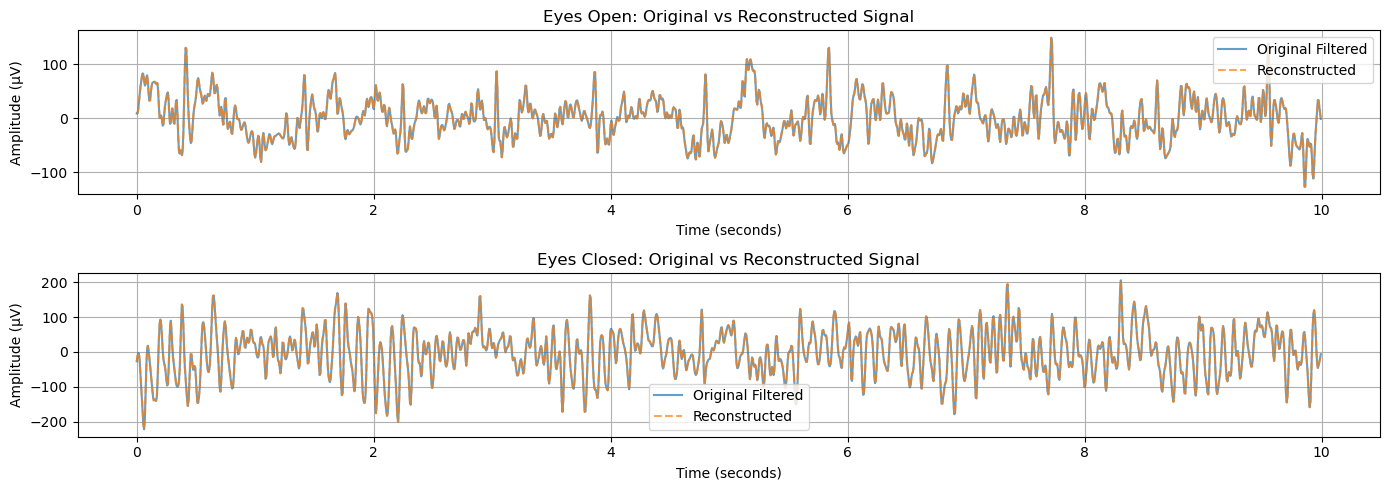

In [24]:
# PLOT RECONSTRUCTION COMPARISON

plt.figure(figsize=(14, 5))

# Eyes Open
plt.subplot(2, 1, 1)
plt.plot(time, data_open_filt * 1e6, label="Original Filtered", alpha=0.7)
plt.plot(time, recon_open * 1e6, '--', label="Reconstructed", alpha=0.7)
plt.title("Eyes Open: Original vs Reconstructed Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid(True)

# Eyes Closed
plt.subplot(2, 1, 2)
plt.plot(time, data_closed_filt * 1e6, label="Original Filtered", alpha=0.7)
plt.plot(time, recon_closed * 1e6, '--', label="Reconstructed", alpha=0.7)
plt.title("Eyes Closed: Original vs Reconstructed Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid(True)

plt.tight_layout()

filename = os.path.join('generated_pics', "Compare Original Filtered vs Reconstructed Signal")
plt.savefig(filename, dpi=300)


plt.show()
